# Agent-Based Modeling of "Live Queue"

In [61]:
%pip install --quiet mesa[rec]

Note: you may need to restart the kernel to use updated packages.


In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import random
import mesa

Definitions of statuses, behavior types, and agent's desires

In [63]:
STATUS_QUEUE_MEMBER = "Queue member" # A status. Some status members have deviated deontology and go away without a warning
STATUS_THE_LAST = "The Last" # Another status

BEHAVIOR_WAITING = "Waiting" # Not a status, but a behavior type

DESIRE_LAWFULLY_ENTER = "Desire to lawfully enter" # Standard desire for a usual visitor. Desire to go in the office and to form a live queue if there is a need.
DESIRE_LOITERING = "Desire to loiter" # Loiterers do not desire to go in office
DESIRE_GO_AWAY = "Desire to go away"

Computational functions

In [64]:
def compute_queue(model):
  queue_length = model.agents.select(lambda a: STATUS_QUEUE_MEMBER in a.statuses)
  return len(queue_length)

def compute_desirers(model):
  lawful_number = model.agents.select(lambda a: DESIRE_LAWFULLY_ENTER in a.desire)
  return len(lawful_number)

def compute_loiterers(model):
  loiterer_number = model.agents.select(lambda a: DESIRE_LOITERING in a.desire)
  return len(loiterer_number)

Functions associated with behavior and physical actions

In [65]:
def loitering(agent): # Non-status function. Just reflection of the behavior
  agent.behavior = BEHAVIOR_WAITING # This type of behavior is identical to queue members' behavior. They are just sitting near the office.

def go_away(agent): # Non-status function. Person just goes away
  agent.model.agents.remove(agent)

def attempt_to_enter(agent): # Usually it is a part of status-function of "Queue member". However it is used by non-members. For example, when there are no queue.
  if agent.model.go_in: # If door to the office is open:
    if agent.next_member !=  None: # If there is someone in the queue after this agent, this person forgets this agent, since the agent goes away
      agent.next_member.previous_member = None
    agent.model.agents.remove(agent)
    agent.model.go_in = False # door is closing
  else:
    agent.behavior = BEHAVIOR_WAITING # if the door is closed, the agent needs to wait


Functions associated with the "social reality" of the "Live queue" organization

In [66]:
def create_queue(agent, first_person): # This is an action, performed by single Declaration "I [agent A] am going after you [agent B]"
    first_person.statuses.append(STATUS_QUEUE_MEMBER) # By means of this Declaration, agent B get installed a status of "Queue member"
    first_person.next_member = agent # Agent B need to remember his successor. It is his status-function now
    agent.statuses.append(STATUS_QUEUE_MEMBER) # Agent A get installed status "Queue member"
    agent.statuses.append(STATUS_THE_LAST) # And the status "The last"
    agent.previous_member = first_person

    agent.behavior = BEHAVIOR_WAITING
    first_person.behavior = BEHAVIOR_WAITING

def leave_queue(agent, previous_member, next_member): # This is a functon that illustrates deviations in deontology
  if agent.deviated_deontology == False: # If this agent's deontology of queue is "standart", the agent need to warn agent's preceding and successer about the agent's leaving
    if STATUS_THE_LAST in agent.statuses:
      new_last = previous_member
      if new_last != None:
        new_last.statuses.append(STATUS_THE_LAST)
        new_last.next_member = None
      agent.model.agents.remove(agent)
    else:
      if agent.next_member != None:
        next_member.previous_member = previous_member
      if agent.previous_member != None:
        previous_member.next_member = next_member
      agent.model.agents.remove(agent)
  else:
      go_away(agent) # If the agent's deontology of queue is "deviated", the agent do not warn any person about the agent's leaving


def join_queue(agent): # Mechanism of joining the organization
  the_last = agent.model.agents.select(lambda a: STATUS_THE_LAST in a.statuses) # The question "Who is the last?" is asked by non-participant to get information
  if len(the_last) > 0:
    the_last = the_last[0]
    the_last.statuses.remove(STATUS_THE_LAST) # The agent is joining the organization by means of the Declaration "I am after you"
    agent.statuses.append(STATUS_QUEUE_MEMBER) # The agent is geting installed two statuses
    agent.statuses.append(STATUS_THE_LAST)
    the_last.next_member = agent # The agent's predecessor need to remember the agent and vice versa
    agent.previous_member = the_last
  else:
    pass

  agent.behavior = BEHAVIOR_WAITING

def lawful_attempt_to_enter(agent): # First attempe to enter the office by lawful newcomer (that is not in the organization)
    if STATUS_QUEUE_MEMBER in agent.statuses:
      return
    others_at_door = agent.model.agents.select(lambda a: a.behavior == BEHAVIOR_WAITING and a != agent)
    if len(others_at_door) > 0:
        queue_members = others_at_door.select(lambda a: STATUS_QUEUE_MEMBER in a.statuses) # The agent checks if a queue exists by asking, "Is anyone going into the office?"
        if len(queue_members) > 0:
            join_queue(agent) # The agent joins the queue if there is a queue
        else:
            willing_people = agent.model.agents.select(lambda a: a.desire == DESIRE_LAWFULLY_ENTER and a != agent)
            if len(willing_people) != 0:
              create_queue(agent, willing_people[0]) # The agent creates queue if there is one waiting person
    else:
        attempt_to_enter(agent) # If there are not any wayting people, the agent attempts to enter

def functioning_in_queue(agent): # Usual functioning in queue
  if agent.previous_member == None: # If there is not any predecessor, it is time to check the door to the office
    attempt_to_enter(agent)
    if agent.next_member == None:
      agent.statuses = [] # If there is no predecessor and successor, there is no more queue. The organization is dissolving
  elif agent.previous_member not in agent.model.agents: # If an agent with deviated deontology has gone away without warning, queue members are getting confused
    model.running = False # The queue is out of order. It is disrupting


Agent and its properties

In [67]:
class HumanAgent(mesa.Agent): # This is an agent and its properties
    def __init__(self, model, desire, deviated_deontology):
        super().__init__(model)
        self.desire = desire
        self.deviated_deontology = deviated_deontology
        self.statuses = []
        self.behavior = None
        self.previous_member = None
        self.next_member = None

Model, its properties and simulation's mechanics

In [68]:
class QueueModel(mesa.Model): # This is a model
    def __init__(self):
        super().__init__()
        self.go_in = False
        self.running = True
        self.steps = 0

        self.datacollector = mesa.DataCollector(
        model_reporters={
            "Queue length": compute_queue,
            "Desirers": compute_desirers,
            "Loiterers": compute_loiterers
        }
    )

    def step(self):
      probability_lawful_spawn = 0.4 # Probability of a lawful agent spawning
      if self.random.random() < probability_lawful_spawn:
        probability_deviated_deontology = 0.05 # The agent's deontology can be deviated. So, this agent will go away without a warning
        if self.random.random() < probability_deviated_deontology:
          HumanAgent.create_agents(model=self, n = 1, desire = DESIRE_LAWFULLY_ENTER, deviated_deontology = True)
        else:
          HumanAgent.create_agents(model=self, n = 1, desire = DESIRE_LAWFULLY_ENTER, deviated_deontology = False)

      probability_loiterer_spawn = 0.1
      if self.random.random() < probability_loiterer_spawn:
        HumanAgent.create_agents(model=self, n = 1, desire = DESIRE_LOITERING, deviated_deontology = False)

      lawful_enterers = self.agents.select(lambda a: a.desire == DESIRE_LAWFULLY_ENTER and STATUS_QUEUE_MEMBER not in a.statuses) # Newcomer's first attempt to enter
      lawful_enterers.shuffle_do(lawful_attempt_to_enter)

      queue_members = self.agents.select(lambda a: STATUS_QUEUE_MEMBER in a.statuses) # Usual functioning
      queue_members.shuffle_do(functioning_in_queue)

      probability_exit_desire = 0.1 # Some agents can get tired. Tired agents are going away. Remember that deviated agents are going without warning
      if len(self.agents) > 0 and self.random.random() < probability_exit_desire:
        tired_person = self.random.choice(self.agents)
        if STATUS_QUEUE_MEMBER in tired_person.statuses:
          leave_queue(tired_person, tired_person.previous_member, tired_person.next_member)
        else:
          go_away(tired_person)

      probability_door_open = 0.3 # This is a chance of vacating the office
      if self.random.random() < probability_door_open:
        self.go_in = True


      self.steps += 1
      self.datacollector.collect(self)


**Running the first simulation and visualizing data**

In [69]:
model = QueueModel()
for _ in range(1000):
    if not model.running:
      break
    model.step()

[Text(0.5, 1.0, 'Queue length over Time')]

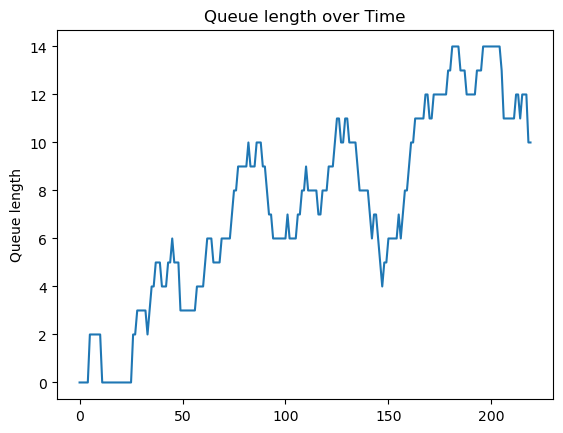

In [70]:
all_data = model.datacollector.get_model_vars_dataframe()
graph_queue = sns.lineplot(data=all_data["Queue length"])
graph_queue.set(title="Queue length over Time")

The plot is ended at the point of the collapse of the organization

**Computing mean model lifespan over 100 iterations**

In [71]:
mean_lifespan = 0
lifespan_list = []
for _ in range(100):
  model = QueueModel()
  for _ in range(3000):
      if not model.running:
        lifespan_list.append(model.steps)
        break
      model.step()
  mean_lifespan = sum(lifespan_list) / len(lifespan_list)
print(mean_lifespan)

810.24


This simulation shows that this type of organization manages agent behavior effectively for approximately 800–1000 steps before breaking down due to inherent structural flaws. This is not a particular queue lifespan, but quantity of steps of the overall model. 